In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/train_features_with_risk.csv")

features = [
    "vehicle_count",
    "pedestrian_count",
    "object_density",
    "avg_bbox_area",
    "max_bbox_area"
]

X = df[features].values
y = df["risk_label"].values

Encode Labels

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)  # ['High', 'Low', 'Medium']

['High' 'Low' 'Medium']


Train / Val / Test Split ✅

In [ ]:
from sklearn.model_selection import train_test_split

# Train (80%) + Temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# Val (10%) + Test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

In [ ]:
import torch.nn as nn

class RiskNet(nn.Module):
    def __init__(self):
        super(RiskNet, self).__init__()
        self.fc1 = nn.Linear(5, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 3)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

model = RiskNet()

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [ ]:
from sklearn.metrics import accuracy_score

epochs = 80

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            _, val_pred = torch.max(val_outputs, 1)

            val_acc = accuracy_score(y_val.numpy(), val_pred.numpy())

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Val Acc: {val_acc:.4f}")

Epoch [10/80], Loss: 1.1325, Val Acc: 0.3320
Epoch [20/80], Loss: 1.0879, Val Acc: 0.3360
Epoch [30/80], Loss: 1.0356, Val Acc: 0.4700
Epoch [40/80], Loss: 0.9631, Val Acc: 0.7460
Epoch [50/80], Loss: 0.8662, Val Acc: 0.8550
Epoch [60/80], Loss: 0.7512, Val Acc: 0.8720
Epoch [70/80], Loss: 0.6331, Val Acc: 0.8740
Epoch [80/80], Loss: 0.5280, Val Acc: 0.8840


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate(model, X, y, name):
    model.eval()
    with torch.no_grad():
        outputs = model(X)
        _, preds = torch.max(outputs, 1)

    acc = accuracy_score(y.numpy(), preds.numpy())

    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y.numpy(), preds.numpy(), target_names=label_encoder.classes_))

# Evaluate all
evaluate(model, X_train, y_train, "Train")
evaluate(model, X_val, y_val, "Validation")
evaluate(model, X_test, y_test, "Test")


Train Accuracy: 0.8909
              precision    recall  f1-score   support

        High       0.86      0.90      0.88      2662
         Low       0.90      0.98      0.94      4611
      Medium       1.00      0.30      0.46       727

    accuracy                           0.89      8000
   macro avg       0.92      0.73      0.76      8000
weighted avg       0.90      0.89      0.88      8000


Validation Accuracy: 0.8840
              precision    recall  f1-score   support

        High       0.86      0.89      0.88       332
         Low       0.89      0.97      0.93       577
      Medium       1.00      0.31      0.47        91

    accuracy                           0.88      1000
   macro avg       0.92      0.72      0.76      1000
weighted avg       0.89      0.88      0.87      1000


Test Accuracy: 0.8930
              precision    recall  f1-score   support

        High       0.86      0.89      0.87       333
         Low       0.91      0.98      0.94       576

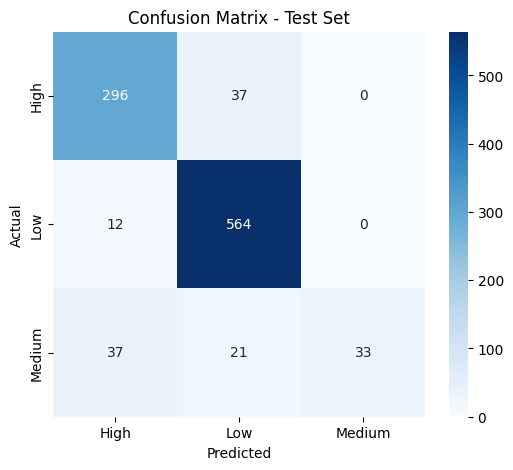

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    outputs = model(X_test)
    _, preds = torch.max(outputs, 1)

cm = confusion_matrix(y_test.numpy(), preds.numpy())

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.show()

In [ ]:
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Get probabilities using softmax
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    probs = F.softmax(test_outputs, dim=1).numpy()

# Convert labels to one-hot format
y_test_np = y_test.numpy()
y_test_bin = label_binarize(y_test_np, classes=[0,1,2])

# Compute ROC-AUC (OvR)
roc_auc = roc_auc_score(y_test_bin, probs, multi_class='ovr')

print("Test ROC-AUC (OvR):", roc_auc)

Test ROC-AUC (OvR): 0.9721333513182837


In [ ]:
roc_auc_per_class = roc_auc_score(y_test_bin, probs, average=None)

for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} ROC-AUC:", roc_auc_per_class[i])

High ROC-AUC: 0.9722075898987443
Low ROC-AUC: 0.9865164766771489
Medium ROC-AUC: 0.9576759873789578


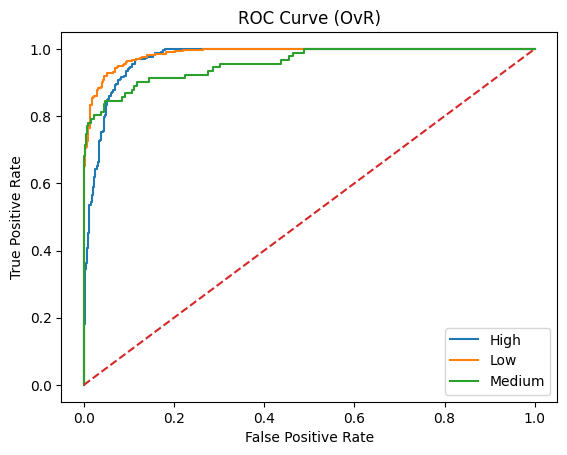

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

for i, class_name in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f"{class_name}")

plt.plot([0,1], [0,1], linestyle='--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (OvR)")
plt.legend()
plt.show()

XAI

In [ ]:
!pip install shap

In [ ]:
import shap
import torch

# Convert tensors to numpy
X_train_np = X_train.numpy()
X_test_np = X_test.numpy()

# Wrapper function
def model_predict(x):
    x_tensor = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        outputs = model(x_tensor)
        probs = torch.softmax(outputs, dim=1)
    return probs.numpy()

In [ ]:
explainer = shap.KernelExplainer(
    model_predict,
    X_train_np[:100]   # small background sample
)

In [ ]:
shap_values = explainer.shap_values(X_test_np[:50])

  0%|          | 0/50 [00:00<?, ?it/s]

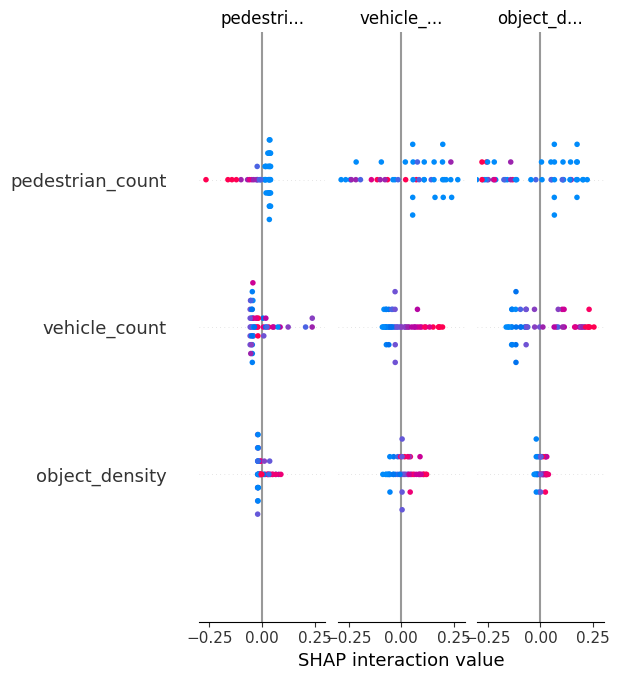

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_np[:50],
    feature_names=features
)

In [ ]:
print(type(shap_values))
print(len(shap_values))  # should be 3 (classes)
print(shap_values[0].shape)  # (samples, features)

<class 'numpy.ndarray'>
50
(5, 3)


In [ ]:
sample_idx = 0

pred_class = model(torch.tensor(X_test_np[sample_idx], dtype=torch.float32)) \
                .argmax().item()

In [ ]:
sample_idx = 0

# Get prediction
x = torch.tensor(X_test_np[sample_idx], dtype=torch.float32)
pred_class = model(x).argmax().item()

# Extract correct SHAP values
shap_sample = shap_values[sample_idx, :, pred_class]

In [ ]:
import shap
shap.initjs()

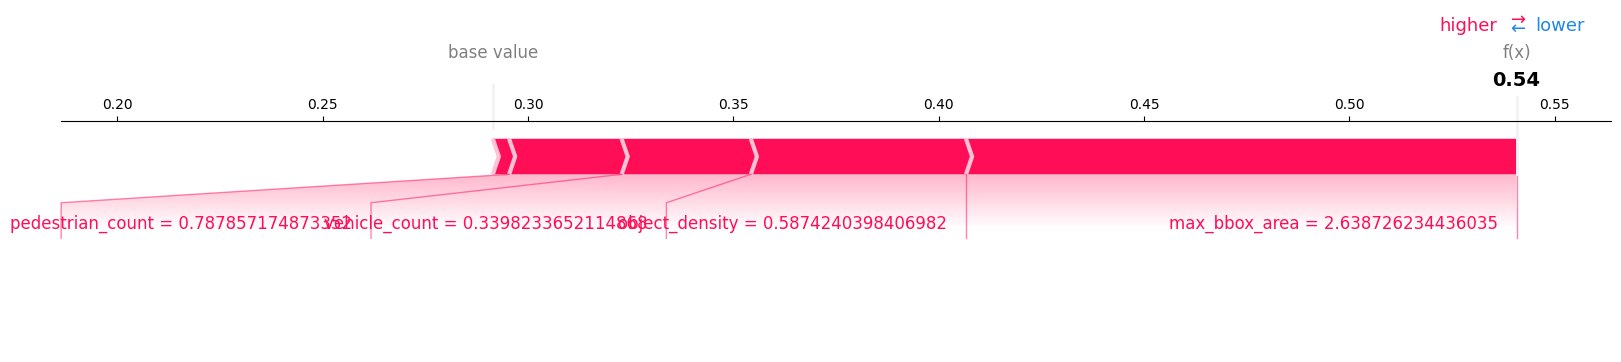

In [ ]:
shap.force_plot(
    explainer.expected_value[pred_class],
    shap_sample,
    X_test_np[sample_idx],
    feature_names=features,
    matplotlib=True
)

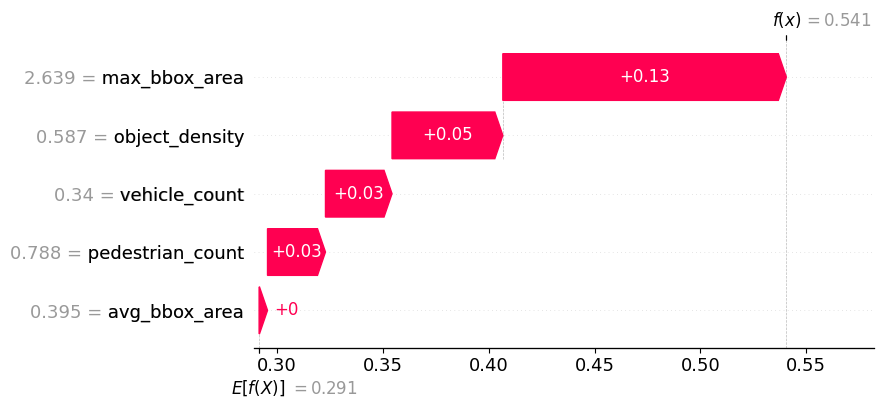

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_sample,
        base_values=explainer.expected_value[pred_class],
        data=X_test_np[sample_idx],
        feature_names=features
    )
)

# DEMONSTRATION

In [ ]:
!pip install ultralytics shap

import numpy as np
import cv2
import torch
import shap
from ultralytics import YOLO
from PIL import Image
from IPython.display import display

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# YOLO
yolo_model = YOLO("yolov8n.pt")

#  trained components (already in notebook)
# model = RiskNet()
# model.load_state_dict(...)
# scaler = ...
# label_encoder = ...
# explainer = ...

In [ ]:
# COCO classes
VEHICLE_CLASSES = [2, 3, 5, 7]  # car, motorcycle, bus, truck
PEDESTRIAN_CLASSES = [0]       # person

In [ ]:
def extract_features_with_display(image_path, model):
    results = model(image_path, conf=0.2)
    boxes = results[0].boxes

    img = cv2.imread(image_path)
    img_h, img_w = img.shape[:2]

    ego_y_thresh = int(img_h * 0.65)
    width_thresh = 0.6 * img_w
    area_thresh = 0.20 * img_h * img_w

    vehicle_count = 0
    pedestrian_count = 0
    bbox_areas = []

    # 🔥 Create a copy for drawing
    annotated = img.copy()

    if boxes is not None:
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls_id = int(box.cls[0])

            box_width = x2 - x1
            box_height = y2 - y1
            box_area = box_width * box_height

            # Ego filtering
            is_ego = (
                y1 > ego_y_thresh and
                (box_width > width_thresh or box_area > area_thresh)
            )

            if is_ego:
                continue

            # 🔥 Draw ONLY valid boxes
            label = "Other"
            color = (255, 255, 255)

            if cls_id in VEHICLE_CLASSES:
                vehicle_count += 1
                bbox_areas.append(box_area)
                label = "Vehicle"
                color = (255, 0, 0)  # Blue

            elif cls_id in PEDESTRIAN_CLASSES:
                pedestrian_count += 1
                bbox_areas.append(box_area)
                label = "Pedestrian"
                color = (0, 255, 0)  # Green

            else:
                continue

            # Draw box
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)

            # Draw label
            cv2.putText(
                annotated,
                label,
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                color,
                2
            )

    total_objects = vehicle_count + pedestrian_count

    object_density = total_objects / (img_h * img_w)
    avg_bbox_area = np.mean(bbox_areas) if bbox_areas else 0
    max_bbox_area = np.max(bbox_areas) if bbox_areas else 0

    features = {
        "vehicle_count": vehicle_count,
        "pedestrian_count": pedestrian_count,
        "object_density": object_density,
        "avg_bbox_area": avg_bbox_area,
        "max_bbox_area": max_bbox_area
    }

    return annotated, features

In [ ]:
def predict(features_dict):
    feature_vector = np.array([list(features_dict.values())])

    scaled = scaler.transform(feature_vector)
    tensor = torch.tensor(scaled, dtype=torch.float32)

    with torch.no_grad():
        output = model(tensor)
        pred = torch.argmax(output, 1).item()

    label = label_encoder.inverse_transform([pred])[0]

    return label, scaled

In [ ]:
def explain(scaled_features):
    shap_values = explainer.shap_values(scaled_features)

    x = torch.tensor(scaled_features, dtype=torch.float32)
    pred_class = model(x).argmax().item()

    shap_sample = shap_values[0, :, pred_class]

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_sample,
            base_values=explainer.expected_value[pred_class],
            data=scaled_features[0],
            feature_names=[
                "vehicle_count",
                "pedestrian_count",
                "object_density",
                "avg_bbox_area",
                "max_bbox_area"
            ]
        )
    )

In [ ]:
def run_demo(image_path):
    print("\n===== INPUT IMAGE =====")
    display(Image.open(image_path))

    print("\n===== YOLO DETECTION =====")
    annotated, feats = extract_features_with_display(image_path, yolo_model)

    plt.figure(figsize=(8,5))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("YOLO Detection (Bounding Boxes)")
    plt.show()

    print("\n===== EXTRACTED FEATURES =====")
    for k, v in feats.items():
        print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

    print("\n===== PREDICTION =====")
    pred, scaled = predict(feats)

    if pred == "High":
        print("🔴 HIGH RISK")
    elif pred == "Medium":
        print("🟡 MEDIUM RISK")
    else:
        print("🟢 LOW RISK")

    print("\n===== SHAP EXPLANATION =====")
    explain(scaled)

In [ ]:
# Copy dataset zip from Drive to Colab workspace
!cp /content/drive/MyDrive/nn_dataset.zip /content/


In [ ]:
!ls /content | grep nn_dataset

nn_dataset.zip


In [ ]:
# Extract dataset
!unzip -q /content/nn_dataset.zip -d /content/nn_dataset

In [ ]:
import os

val_images = [f for f in os.listdir("/content/nn_dataset/Data/val") if f.endswith(".jpg")]
sample_image_path = "/content/nn_dataset/Data/val/" + val_images[0]


===== INPUT IMAGE =====


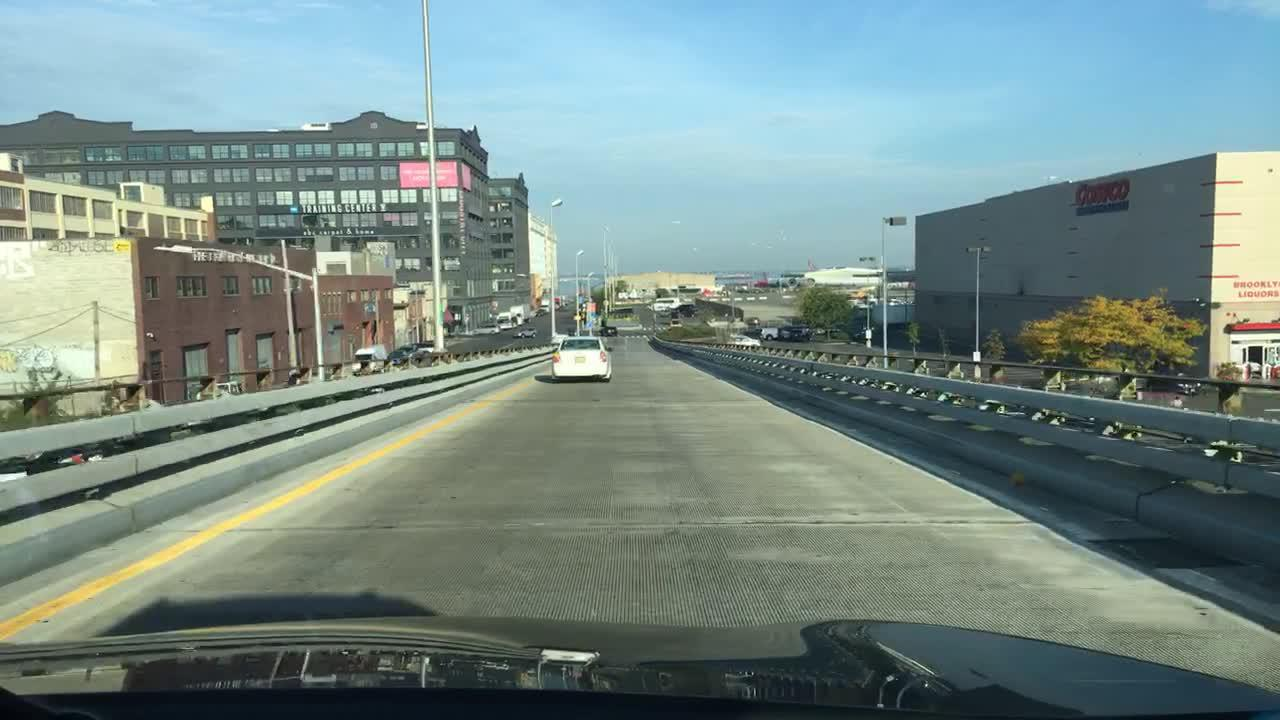


===== YOLO DETECTION =====

image 1/1 /content/nn_dataset/Data/val/b1cebfb7-284f5117.jpg: 384x640 5 cars, 267.6ms
Speed: 5.5ms preprocess, 267.6ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


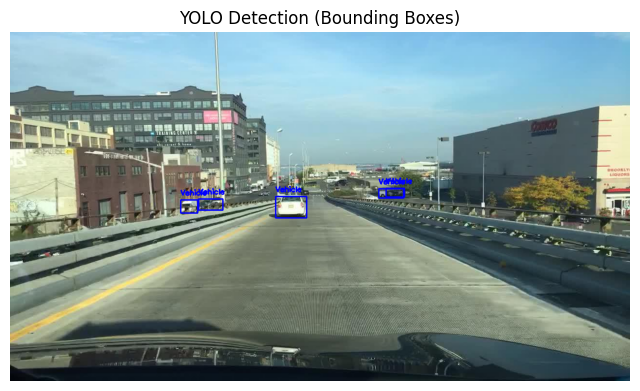


===== EXTRACTED FEATURES =====
vehicle_count: 5
pedestrian_count: 0
object_density: 0.0000
avg_bbox_area: 1312.8000
max_bbox_area: 2816

===== PREDICTION =====
🟢 LOW RISK

===== SHAP EXPLANATION =====


  0%|          | 0/1 [00:00<?, ?it/s]

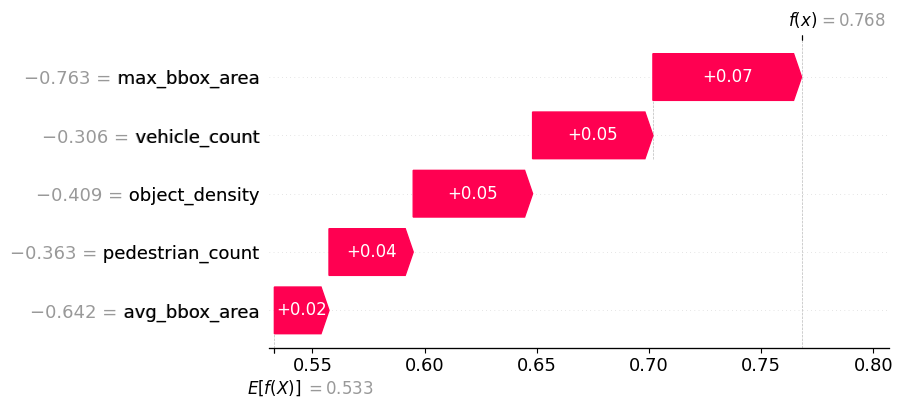

In [ ]:
run_demo(sample_image_path)